# [Computational Social Science] Project 4: Unsupervised Learning

**Enter your Name:** Alan Mozaffari

*Semester:* Fall 2025

## Data Description and Preprocessing

For this project, you will explore data from the [National Health and Nutrition Examination Survey](https://www.kaggle.com/cdc/national-health-and-nutrition-examination-survey?select=questionnaire.csv). NHANES is a unique study that combines survey methodology with in-person medical examinations to create a dataset with demographic information, health indicators, and health outcomes.

We start by importing the data and doing some preliminary preprocessing for you. We import some libraries that will be helpful as well. 'SEQN' is the ID number for each respondent, and 'HSD010' will be our target outcome. [HSD010](https://wwwn.cdc.gov/Nchs/Nhanes/2013-2014/HSQ_H.htm#HSD010) asks for the respondent's self reported health condition, which can range from "excellent" to "poor."

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import random
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
#from keras.models import Sequential
#from keras.layers import Dense, Dropout

#these work for me i think because i have an M1 mac
import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
sns.set_style("darkgrid")
from sklearn.model_selection import train_test_split

In [2]:
# Load nhanes data
nhanes = pd.read_csv('nhanes.csv')
# Get the ID numbers for each observation (seqn)
seqn = nhanes['SEQN']
# Get the target, "self-reported health condition," HSD010
hsd010 = nhanes['HSD010']
# Drop SEQN from the dataframe and then apply the standard scaler
nhanes = nhanes.drop(['SEQN', 'HSD010'], axis = 1)
nhanes_scaled = pd.DataFrame(StandardScaler().fit_transform(nhanes),
                             columns = nhanes.columns)
# Add the ID and target back in
nhanes_scaled['SEQN'] = seqn
nhanes_scaled['HSD010'] = hsd010
nhanes_scaled = nhanes_scaled.set_index('SEQN')
nhanes_scaled.head()

,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,DR1MNRSP,DR1HELPD,DBQ095Z,...,OHQ770,OHQ845,PAAQUEX,SMQ860,SMQ870,SMQ872,SMQ874,SMQ878,SMAQUEX.x,HSD010
SEQN,,,,,,,,,,,,,,,,,,,,,
73568,0.0,2.034312,0.0,0.324834,-0.393906,1.085853,-0.194202,-0.057306,0.128246,-0.189513,...,0.383802,-0.646584,-0.484200,1.125008,0.0,-2.081666,1.087115,1.463404,0.612440,1
73576,0.0,0.261930,0.0,-3.078499,0.568251,0.634362,-0.194202,-0.057306,0.128246,0.080373,...,0.383802,-1.539259,-0.484200,1.125008,0.0,-2.081666,1.087115,-0.683338,-1.632812,1
73579,0.0,0.728346,0.0,0.324834,1.530407,-1.623092,-0.194202,-0.057306,0.128246,-0.189513,...,0.383802,-1.539259,2.065262,-0.888883,0.0,0.480384,-0.919866,-0.683338,-1.632812,2
73581,0.0,-0.857470,0.0,0.324834,0.480782,1.085853,-0.194202,-0.057306,0.128246,0.080373,...,0.383802,-0.646584,-0.484200,1.125008,0.0,0.480384,-0.919866,-0.683338,0.612440,2
73584,0.0,0.495138,0.0,0.324834,0.305844,-1.623092,-0.194202,-0.057306,0.128246,0.080373,...,-2.605509,0.246091,2.065262,1.125008,0.0,0.480384,-0.919866,1.463404,-1.632812,3


## Plots

Let's take a look at the data. Below we visualize boxplots of family income to federal poverty line ratio ('INDFMPIR') and self-reported health condition. Notice how there are some clear patterns (the lower the ratio, the lower reported health condition), but it's not a perfect separation. We have 240+ features in our dataset, and we likely have several features in our dataset that highly correlate with our family income-poverty line ratio measure - PCA will help us simplify these.

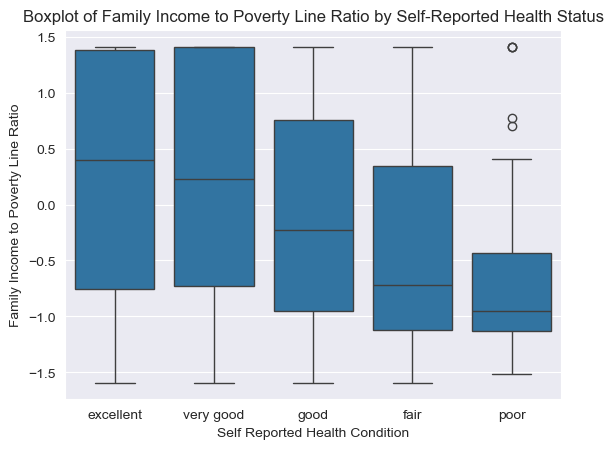

In [3]:
# Create a binary version of hsd010 where 1-3 are "good" and 4-5 are "poor"
nhanes_scaled['HSD010_binary'] = hsd010_binary = nhanes_scaled['HSD010'].replace(
    [1, 2, 3, 4, 5], ['good', 'good', 'good', 'poor', 'poor']) 
# Recode the original hsd010 with the string labels
nhanes_scaled['HSD010'] = nhanes_scaled['HSD010'].replace(
    [1, 2, 3, 4, 5], ['excellent', 'very good', 'good', 'fair', 'poor'])
# Boxplot of hsd010
ax = sns.boxplot(x = 'HSD010', y = 'INDFMPIR', data = nhanes_scaled)
ax.set(xlabel = "Self Reported Health Condition",
      ylabel = "Family Income to Poverty Line Ratio")
ax.set_title("Boxplot of Family Income to Poverty Line Ratio by Self-Reported Health Status")
plt.show()

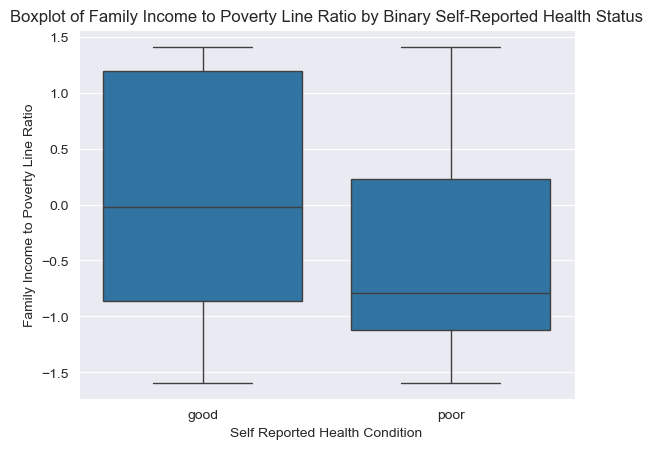

In [4]:
# Boxplot of hsd010_binary
ax = sns.boxplot(x = 'HSD010_binary', y = 'INDFMPIR', data = nhanes_scaled)
ax.set(xlabel = "Self Reported Health Condition",
      ylabel = "Family Income to Poverty Line Ratio")
ax.set_title("Boxplot of Family Income to Poverty Line Ratio by Binary Self-Reported Health Status")
plt.show()

Family income also is not necessarily well correlated with measured health outcomes. See below where we look at the relationship between Body Mass Index (BMI) and the family income-poverty line ratio, and shade points by self-reported health condition. It's hard to find a clear pattern - this is where clustering may come in handy. 

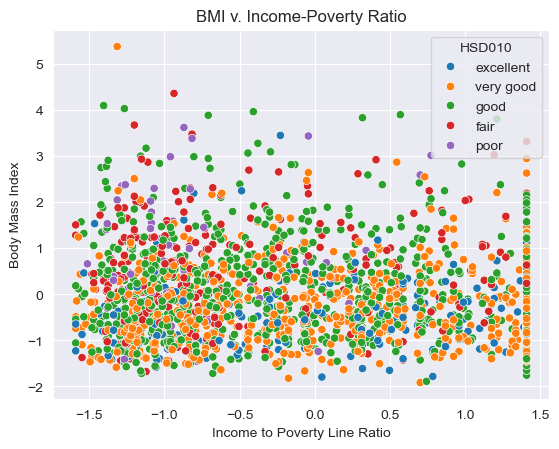

In [5]:
ax = sns.scatterplot(x = "INDFMPIR", y = "BMXBMI", hue = "HSD010", palette = "tab10", data = nhanes_scaled)
ax.set(xlabel = "Income to Poverty Line Ratio",
      ylabel = "Body Mass Index")
ax.set_title("BMI v. Income-Poverty Ratio")
plt.show()

Before we move to working on unsupervised methods, we'll drop our target variables again:

In [6]:
#for later plotting
y = nhanes_scaled['HSD010']   
y_binary = nhanes_scaled['HSD010_binary']  


nhanes_scaled = nhanes_scaled.drop(['HSD010', 'HSD010_binary'], axis = 1)

 

## Principal Component Analysis

Conduct a Principal Component Analysis (PCA) of the nhanes data. The data has already been prepared for you, so you can work directly on nhanes_scaled. Be sure to do the following:

- Choose the number of components and provide 1-2 sentences about your choice of the number of components. 
- Plot a barplot of the variation explained by each component. *Hint*: look at the attributes associated with your model. 
- Choose how many components you will use to fit a supervised learning model and provide 1-2 sentences to explain that choice.
- Plot a 2D scatterplot of the first two components and provide 1-2 sentences analyzing the plot.

### Train PCA and Discuss Number of Components

In [7]:
#PCA with all components

pca_all = PCA() 
principalComponents_nhanes_all = pca_all.fit_transform(nhanes_scaled)

#PCA with 10 components

pca = PCA(n_components=10)
principalComponents_nhanes = pca.fit_transform(nhanes_scaled)

pca_df = pd.DataFrame(data = principalComponents_nhanes, 
                      columns = ['principal component 1', 
                                 'principal component 2',
                                'principal component 3',
                                'principal component 4',
                                'principal component 5',
                                'principal component 6',
                                'principal component 7',
                                'principal component 8',
                                'principal component 9',
                                'principal component 10'])

#pca_df.head()


**Answer:** I initially looked at all possible components, while also limiting the model to 10. I knew there would be some diminishing return on variance explained fairly quickly, so limited the number of components to 10 to see when that will occur. However, I figured there might be a chance that each component does not explain as much variance given the number of covariates in the dataset, so I wanted to see the full number of components as well to make my decision (see below)

### Barplot of Components

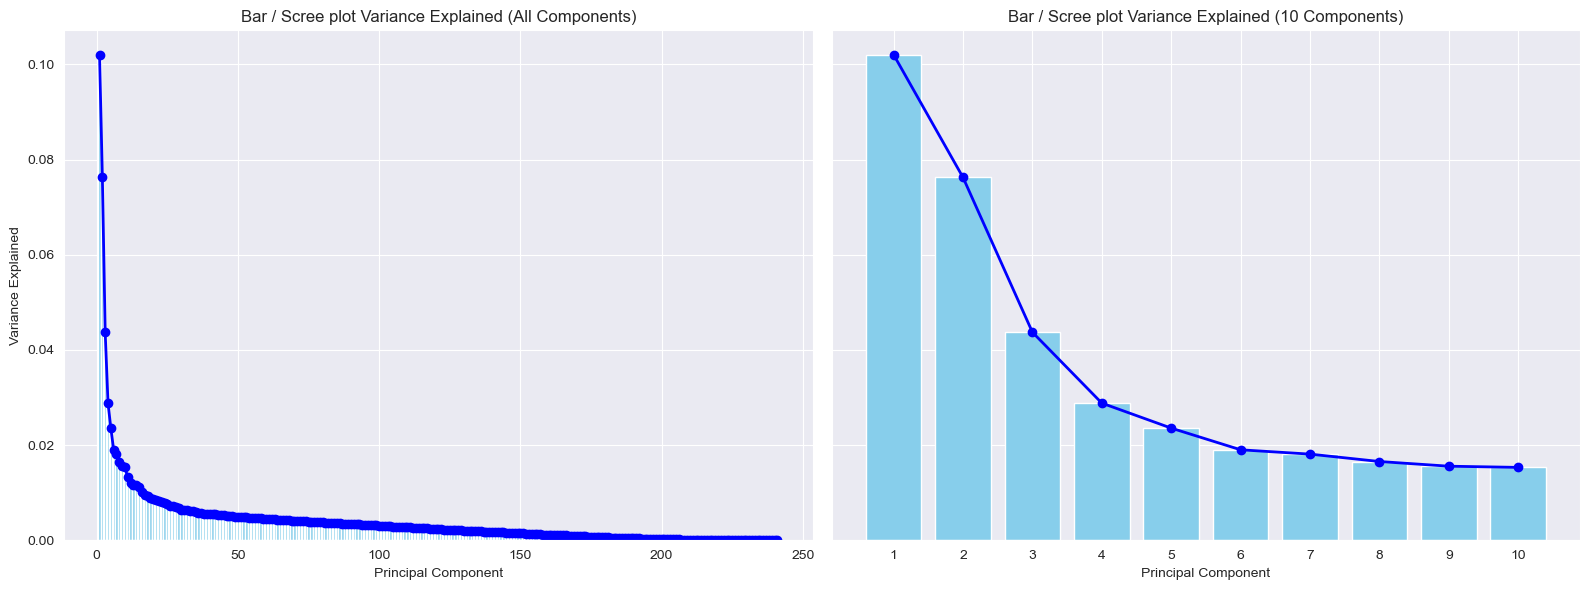

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# -------------------------
# Plot 1: PCA with all components
# -------------------------
PC_values_all = np.arange(pca_all.n_components_) + 1
axes[0].bar(PC_values_all, pca_all.explained_variance_ratio_, color='skyblue')
axes[0].plot(PC_values_all, pca_all.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
axes[0].set_title('Bar / Scree plot Variance Explained (All Components)')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained')


# -------------------------
#  Plot 2: PCA with 10 components 
# -------------------------

PC_values = np.arange(pca.n_components_) + 1
axes[1].bar(PC_values, pca.explained_variance_ratio_, color='skyblue')
axes[1].plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
axes[1].set_title('Bar / Scree plot Variance Explained (10 Components)')
axes[1].set_xlabel('Principal Component')
axes[1].set_xticks(PC_values)

plt.tight_layout()
plt.show()

In [9]:
# how many components explain 80% of the variance
np.argmax(np.cumsum(pca_all.explained_variance_ratio_) >= 0.80) + 1

86

### How many components will you use to fit a supervised learning model?

The Bar/Scree Plot above on the right with 10 components suggests that after 6 components the additional variance explained starts to become very minimal. While I would be inclined to use the elbow method to thus pick 6 components in my supervised learning model, the first 6 components explain about 30% of the variance, which is not much. I wanted to use a liberal estimate of about 80% of variance expalined for my threshold, and given the Bar/Scree Plot above and on the left, and better identifying how many of the first components explain 80% of the variance, I came up with 86. I will therefore go with 86 components. Compared to the ~240 predictors in the dataset, reducing it to 86 components is still a substanail amount without sacrificing too much to lose explalined variance, even though it would be nice to reduce it even further. 

### 2D Scatterplot of the first two components

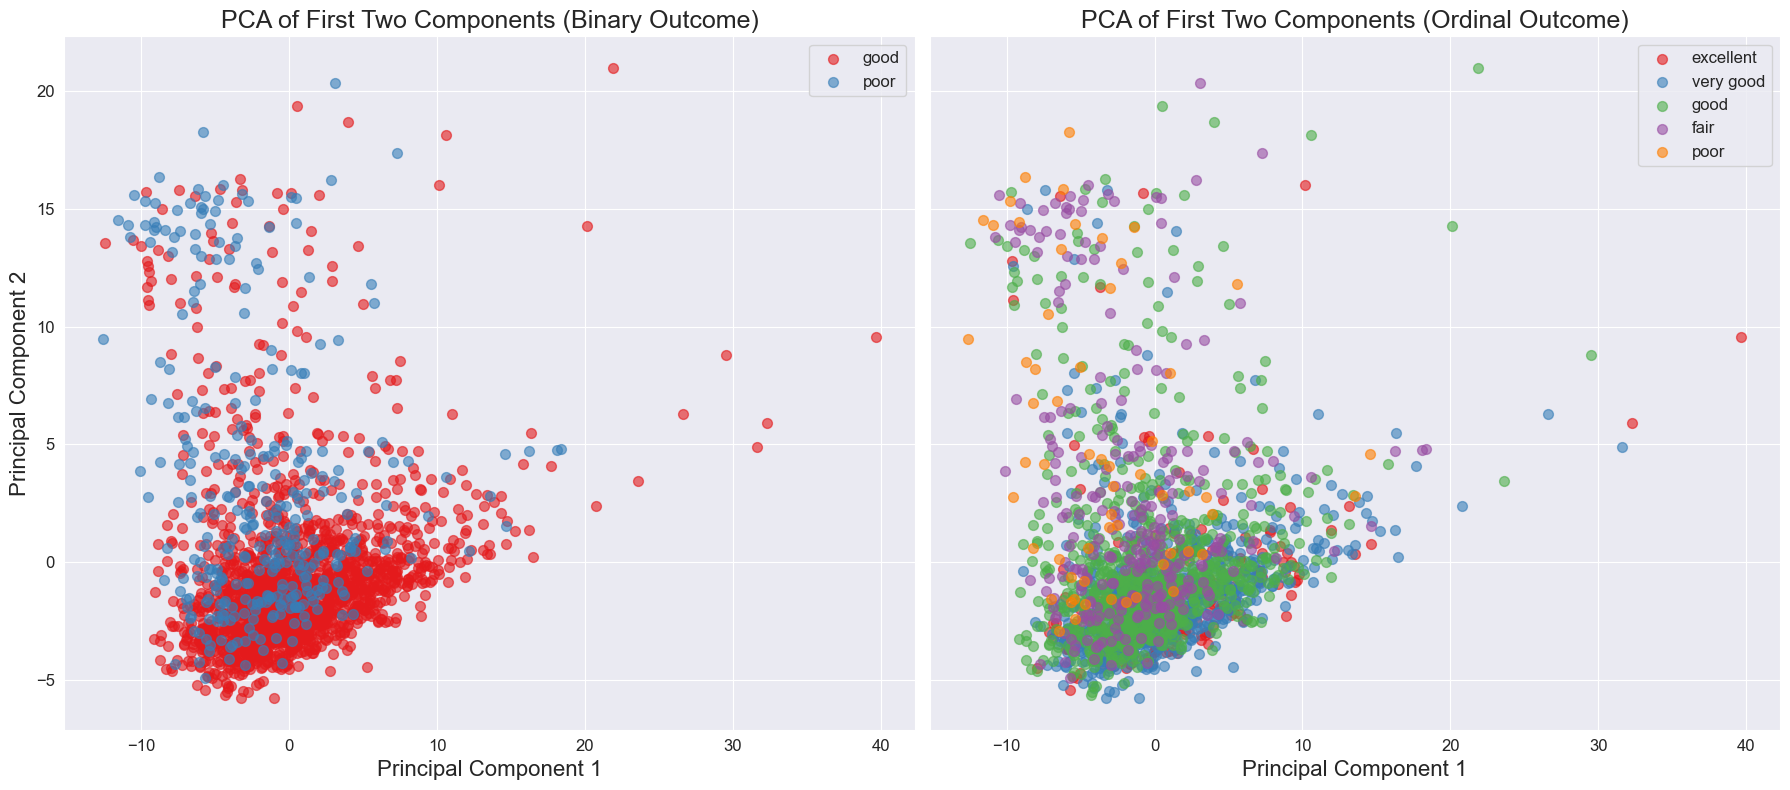

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True)

# -------------------------
# Binary outcome
# -------------------------

axes[0].set_title(
    "PCA of First Two Components (Binary Outcome)", fontsize=18
)
axes[0].set_xlabel('Principal Component 1', fontsize=16)
axes[0].set_ylabel('Principal Component 2', fontsize=16)
axes[0].tick_params(axis='both', labelsize=12)

targets_binary = ['good', 'poor']
colors_binary = sns.color_palette("Set1", 2)

for target, color in zip(targets_binary, colors_binary):
    indicesToKeep = y_binary.values == target
    axes[0].scatter(
        pca_df.loc[indicesToKeep, 'principal component 1'],
        pca_df.loc[indicesToKeep, 'principal component 2'],
        color=color,
        s=50,
        alpha=0.6,
        label=target
    )

axes[0].legend(prop={'size': 12})

# -------------------------
# Ordinal outcome
# -------------------------

axes[1].set_title(
    "PCA of First Two Components (Ordinal Outcome)", fontsize=18
)
axes[1].set_xlabel('Principal Component 1', fontsize=16)
axes[1].tick_params(axis='both', labelsize=12)

targets_ordinal = ['excellent', 'very good', 'good', 'fair', 'poor']
colors_ordinal = sns.color_palette("Set1", 5)

for target, color in zip(targets_ordinal, colors_ordinal):
    indicesToKeep = y.values == target
    axes[1].scatter(
        pca_df.loc[indicesToKeep, 'principal component 1'],
        pca_df.loc[indicesToKeep, 'principal component 2'],
        color=color,
        s=50,
        alpha=0.6,
        label=target
    )

axes[1].legend(prop={'size': 12})

plt.tight_layout()
plt.show()

**Answer:** Looking at the plot with just the binary outcome, there seems to be some distinguishable pattern between the two components, based on their dispersion: principal component 1 is largely concentrated in the bottom left corner, while principal component 2 is spread along the y axis between -10 and 0 (of principal component 1). However, there is a lot of overlap of components, especially when looking at the ordinal outcomes, and it is ultimately hard to distinguish different clusters of self-reported health by just looking at the first two components.

## Clustering

- Choose a clustering algorithm and explain it in 1-2 sentences.
- Cluster the nhanes data. Detail any choice you need to make with regards to number of clusters, and how you arrived at that choice. For instance, you might use the [elbow method](https://en.wikipedia.org/wiki/Elbow_method_(clustering)) if you choose k-means.
- Plot your clusters on top of BMI v. Income Poverty Ratio Plot. Describe what you see in 1-2 sentences.
- Retrain the clustering algorithm, but this time use your PCA results instead of the original dataframe. Plot the clusters on top of the 2D PCA scatterplot from the previous step. Describe your results in 1-2 sentences.

### Choose a Clustering Algorithm

**Answer:** I chose K-means clustering since it may better identify more distinct clusters. It is an unsupervised machine learning algorithm that requires a pre-determined number of clusters *k* as centroids of each cluster, which is the average location of each assigned data point to that cluster. Each data point is iteratively assigned to the nearest centroid, and then the model updates the centroids to minimize the distance between the points and other centroids. This process is repeated until cluster assignments then stabilize.

### Cluster nhanes

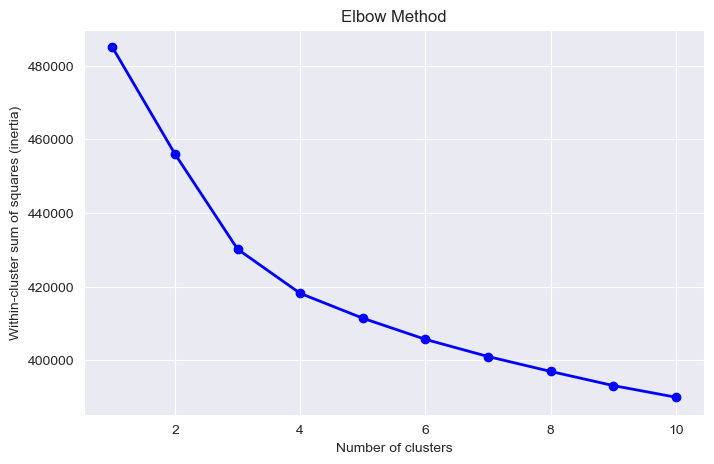

In [11]:
#elbow method
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=123, n_init=10)
    kmeans.fit(nhanes_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, 'bo-', linewidth=2)
plt.xlabel('Number of clusters')
plt.ylabel('Within-cluster sum of squares (inertia)')
plt.title('Elbow Method')
plt.show()

**Answer:** Will use 4 clusters given elbow method, where the rate of decrease changes the least after 4 clusters

In [12]:
#clustering 
kmeans = KMeans(n_clusters=4,
                n_init=10,
                max_iter=300,
                random_state = 123
                ).fit(nhanes_scaled)


### Plot your clusters on top of the BMI v. Income Poverty Ratio Plot

In [13]:
#for plotting consistency purposes
cluster_palette = {
    "0": "#E41A1C",  # red
    "1": "#377EB8",  # blue
    "2": "#4DAF4A",  # green
    "3": "#984EA3"   # purple
}


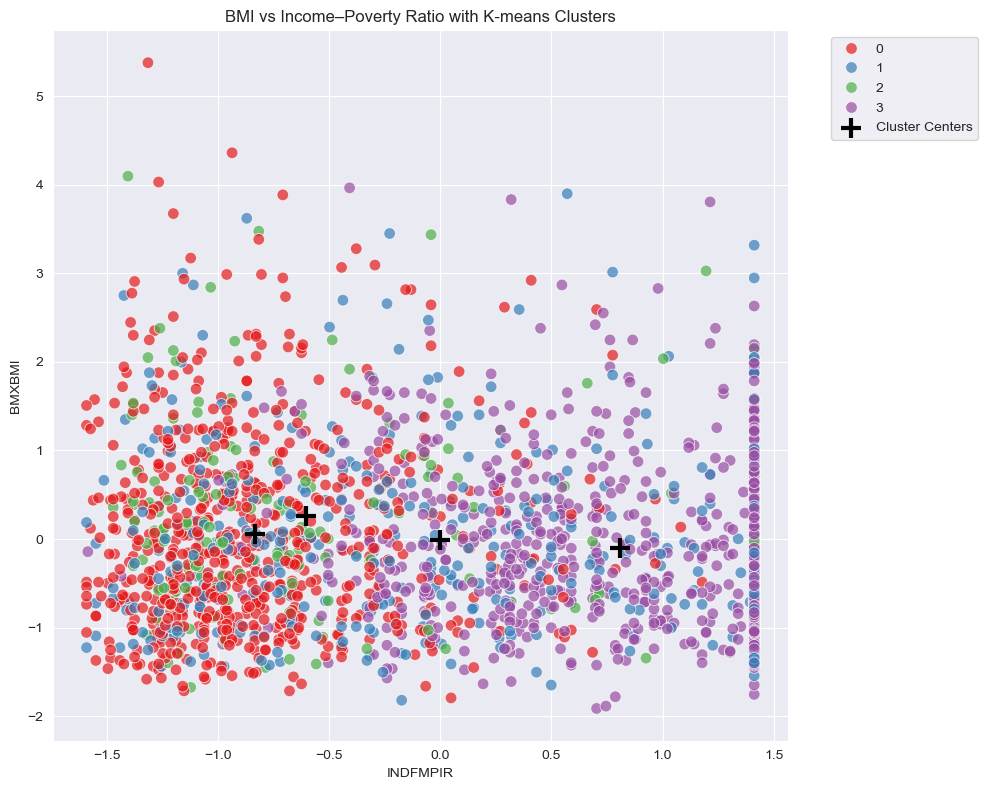

In [14]:
# BMI vs Income plot
plot_df = pd.concat([nhanes_scaled, y], axis=1)
plot_df["cluster"] = kmeans.labels_.astype(str)

plt.figure(figsize=(10, 8))
ax = sns.scatterplot(
    x="INDFMPIR",
    y="BMXBMI",
    hue="cluster",
    hue_order=["0","1","2","3"],  
    palette=cluster_palette,       
    data=plot_df,
    s=70,
    alpha=0.7
)

# Cluster centers
centers_2d = plot_df.groupby("cluster")[["INDFMPIR", "BMXBMI"]].mean()
ax.scatter(
    centers_2d["INDFMPIR"],
    centers_2d["BMXBMI"],
    s=200,
    c="black",
    marker="+",
    linewidth=3,
    label="Cluster Centers"
)
ax.set(title="BMI vs Income–Poverty Ratio with K-means Clusters")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Answer:** There is a bit of a clearer differentiation of clustering here. We see mostly cluster 3 spreading across a range of BMIs, but within -0.5 to 1.5 family income-poverty line ratio, while cluster 0 is within -1.5 - 0 family income-poverty line ratio. Clusters 1 and 2 seem much less prevalent, and seem to not be that concentrated at any particular place in the plot. The centroids of each cluster all are around 0 BMI index, but range across family income-poverty line ratio.

### Retrain the clustering algorithm on PCA components and plot clusters on your 2D scatter

In [15]:
kmeans = KMeans(n_clusters=4,
                n_init=10,
                max_iter=300,
                random_state = 123
                ).fit(pca_df)

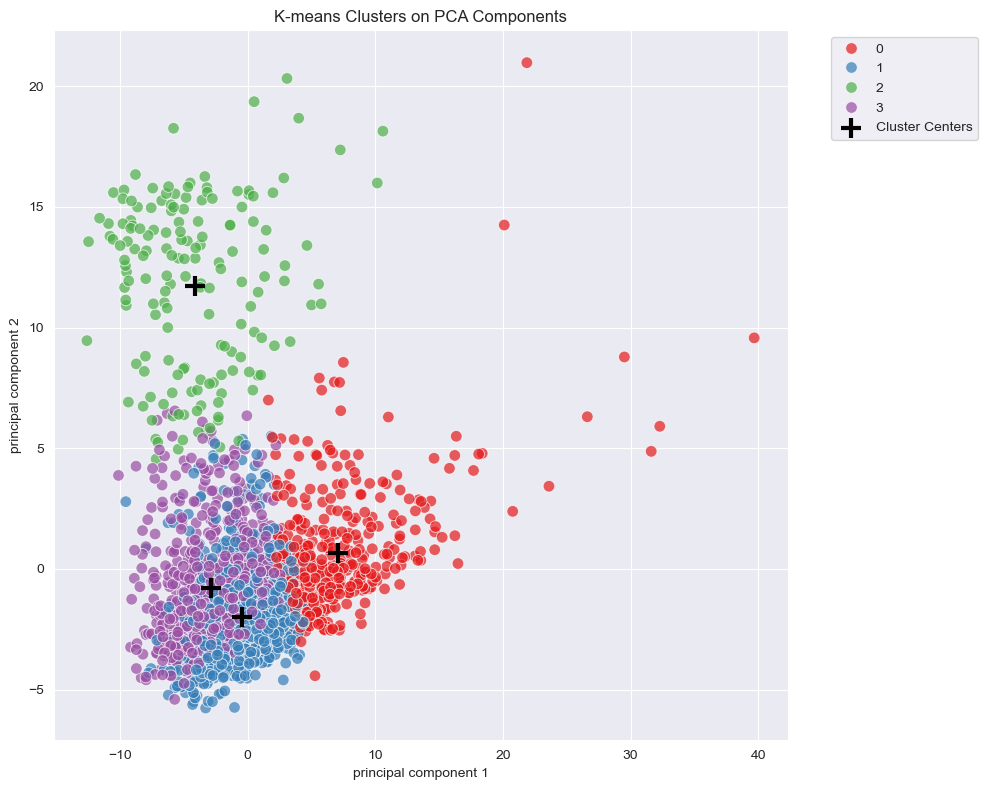

In [16]:
# PCA plot
pca_df["cluster"] = kmeans.labels_.astype(str)
plt.figure(figsize=(10, 8))
ax = sns.scatterplot(
    x="principal component 1",
    y="principal component 2",
    hue="cluster",
    hue_order=["0","1","2","3"],  
    palette=cluster_palette,
    data=pca_df,
    s=70,
    alpha=0.7
)

# Cluster centers
centers_2d = pca_df.groupby("cluster")[["principal component 1", "principal component 2"]].mean()
ax.scatter(
    centers_2d["principal component 1"],
    centers_2d["principal component 2"],
    s=200,
    c="black",
    marker="+",
    linewidth=3,
    label="Cluster Centers"
)
ax.set(title="K-means Clusters on PCA Components")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Answer:** There are clearer differentiation and separation of clusters here looking at the first two principal components. Clusters 1 and 3 concentrate at the bottom left (and their centroids are close to each other), while cluster 0 concentrates right of both of them. Cluster 2 however is much sparser and extends higher along principal component 2.

## Neural Network

Now we are ready to predict! Do the following:

- Choose either HSD010 or HSD010\_binary as your target outcome.  
- Train a neural network using the original features. Much of the code to train a basic neural net has been set up for you, but you will need to fill in a couple of missing pieces.
- Train a neural network using only your PCA components as features.
- Train a neural network using your PCA components and the predicted class membership from your clustering algorithm as features.
- Compare and contrast how well each algorithm did. Which featurization technique would you pick and why?

Below we provide a template for training a neural network. Use this template for training on the original features, on the PCA components, and the PCA components + the predicted classes from your clusters.

### Neural Network on Original Features

In [17]:
# partition data
# -----------
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y_binary) 

X = nhanes_scaled

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size = .25, 
                                                    random_state = 10)

In [18]:
# load libraries
# -----------
import keras
from keras.utils import to_categorical

num_classes = 10

# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
num_classes = y_test.shape[1]

In [19]:
# create neural network model
# -----------
seed_value = 123
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)


model = Sequential()

model.add(Dense(128, input_dim= X_train.shape[1], kernel_initializer= "normal", activation= "relu"))

model.add(Dense(64, kernel_initializer= "normal", activation= "relu")) 

model.add(Dense(num_classes, activation='softmax'))

## Add any additional layers you wish here

model.compile(loss= "categorical_crossentropy", optimizer= "adam", metrics=["accuracy"])

mod = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs= 10, batch_size= 200, verbose=2 )


/opt/anaconda3/envs/CSS/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-12-17 17:52:36.623628: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-12-17 17:52:36.623713: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-17 17:52:36.623728: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-12-17 17:52:36.623982: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-17 17:52:36.624006: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Create

Epoch 1/10


2025-12-17 17:52:37.123582: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


8/8 - 1s - 126ms/step - accuracy: 0.2642 - loss: 2.2653 - val_accuracy: 0.4748 - val_loss: 2.1489
Epoch 2/10
8/8 - 0s - 19ms/step - accuracy: 0.5607 - loss: 1.9572 - val_accuracy: 0.5950 - val_loss: 2.0323
Epoch 3/10
8/8 - 0s - 19ms/step - accuracy: 0.6460 - loss: 1.8081 - val_accuracy: 0.6318 - val_loss: 1.9549
Epoch 4/10
8/8 - 0s - 18ms/step - accuracy: 0.6977 - loss: 1.6944 - val_accuracy: 0.6783 - val_loss: 1.8863
Epoch 5/10
8/8 - 0s - 19ms/step - accuracy: 0.7506 - loss: 1.5885 - val_accuracy: 0.7326 - val_loss: 1.7879
Epoch 6/10
8/8 - 0s - 18ms/step - accuracy: 0.7849 - loss: 1.4458 - val_accuracy: 0.7403 - val_loss: 1.6592
Epoch 7/10
8/8 - 0s - 17ms/step - accuracy: 0.8036 - loss: 1.3016 - val_accuracy: 0.7655 - val_loss: 1.5268
Epoch 8/10
8/8 - 0s - 17ms/step - accuracy: 0.8204 - loss: 1.1622 - val_accuracy: 0.7752 - val_loss: 1.4094
Epoch 9/10
8/8 - 0s - 18ms/step - accuracy: 0.8307 - loss: 1.0485 - val_accuracy: 0.7849 - val_loss: 1.3142
Epoch 10/10
8/8 - 0s - 17ms/step - acc

### Neural Network on Principal Components

In [20]:
seed_value = 123
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)


# -------------------------
# Use PCA components as features
# -------------------------
pca = PCA(n_components=86)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.fit_transform(X_test)



# -------------------------
# Train Neural Network with PCA
# -------------------------

model = Sequential()

model.add(Dense(128, input_dim= X_train_pca.shape[1], kernel_initializer= "normal", activation= "relu"))

model.add(Dense(64, kernel_initializer= "normal", activation= "relu")) 

model.add(Dense(num_classes, activation='softmax'))

## Add any additional layers you wish here

model.compile(loss= "categorical_crossentropy", optimizer= "adam", metrics=["accuracy"])

mod2 = model.fit(X_train_pca, y_train, validation_data=(X_test_pca, y_test), epochs= 10, batch_size= 200, verbose=2 )



Epoch 1/10


/opt/anaconda3/envs/CSS/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 - 1s - 108ms/step - accuracy: 0.1686 - loss: 2.3113 - val_accuracy: 0.2849 - val_loss: 2.2095
Epoch 2/10
8/8 - 0s - 18ms/step - accuracy: 0.4264 - loss: 2.0274 - val_accuracy: 0.5233 - val_loss: 2.0571
Epoch 3/10
8/8 - 0s - 22ms/step - accuracy: 0.5762 - loss: 1.8244 - val_accuracy: 0.6182 - val_loss: 1.9337
Epoch 4/10
8/8 - 0s - 19ms/step - accuracy: 0.6602 - loss: 1.6431 - val_accuracy: 0.6512 - val_loss: 1.8187
Epoch 5/10
8/8 - 0s - 18ms/step - accuracy: 0.7248 - loss: 1.4670 - val_accuracy: 0.6880 - val_loss: 1.7087
Epoch 6/10
8/8 - 0s - 18ms/step - accuracy: 0.7629 - loss: 1.3044 - val_accuracy: 0.7074 - val_loss: 1.6094
Epoch 7/10
8/8 - 0s - 19ms/step - accuracy: 0.7939 - loss: 1.1564 - val_accuracy: 0.7326 - val_loss: 1.4953
Epoch 8/10
8/8 - 0s - 18ms/step - accuracy: 0.8178 - loss: 1.0140 - val_accuracy: 0.7481 - val_loss: 1.3761
Epoch 9/10
8/8 - 0s - 17ms/step - accuracy: 0.8424 - loss: 0.8824 - val_accuracy: 0.7461 - val_loss: 1.2577
Epoch 10/10
8/8 - 0s - 17ms/step - acc

### Neural Network on Principal Components + Cluster Membership

In [21]:
seed_value = 123
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

# -------------------------
# Use PCA components as features + predicted K Means clustering class membership
# -------------------------

kmeans.fit(X_train_pca)

cluster_train = kmeans.labels_                
cluster_test  = kmeans.predict(X_test_pca) 

ohe = OneHotEncoder(sparse_output=False)

cluster_train_ohe = ohe.fit_transform(cluster_train.reshape(-1, 1))
cluster_test_ohe  = ohe.transform(cluster_test.reshape(-1, 1))

X_train_pca_kmc = np.hstack([X_train_pca, cluster_train_ohe])
X_test_pca_kmc  = np.hstack([X_test_pca, cluster_test_ohe])


# -------------------------
# Train Neural Network with PCA + K Means Clusters
# -------------------------


model = Sequential()

model.add(Dense(128, input_dim= X_train_pca_kmc.shape[1], kernel_initializer= "normal", activation= "relu"))

model.add(Dense(64, kernel_initializer= "normal", activation= "relu")) 

model.add(Dense(num_classes, activation='softmax'))

## Add any additional layers you wish here

model.compile(loss= "categorical_crossentropy", optimizer= "adam", metrics=["accuracy"])

mod3 = model.fit(X_train_pca_kmc, y_train, validation_data=(X_test_pca_kmc, y_test), epochs= 10, batch_size= 200, verbose=2 )



/opt/anaconda3/envs/CSS/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
8/8 - 1s - 107ms/step - accuracy: 0.1854 - loss: 2.2907 - val_accuracy: 0.3450 - val_loss: 2.1402
Epoch 2/10
8/8 - 0s - 18ms/step - accuracy: 0.4935 - loss: 1.9341 - val_accuracy: 0.5872 - val_loss: 1.9057
Epoch 3/10
8/8 - 0s - 19ms/step - accuracy: 0.6505 - loss: 1.6529 - val_accuracy: 0.6822 - val_loss: 1.6872
Epoch 4/10
8/8 - 0s - 20ms/step - accuracy: 0.7390 - loss: 1.3796 - val_accuracy: 0.7267 - val_loss: 1.4676
Epoch 5/10
8/8 - 0s - 20ms/step - accuracy: 0.7984 - loss: 1.1105 - val_accuracy: 0.7539 - val_loss: 1.2622
Epoch 6/10
8/8 - 0s - 18ms/step - accuracy: 0.8288 - loss: 0.8743 - val_accuracy: 0.7733 - val_loss: 1.0876
Epoch 7/10
8/8 - 0s - 18ms/step - accuracy: 0.8559 - loss: 0.6881 - val_accuracy: 0.7849 - val_loss: 0.9367
Epoch 8/10
8/8 - 0s - 20ms/step - accuracy: 0.8766 - loss: 0.5527 - val_accuracy: 0.7946 - val_loss: 0.8160
Epoch 9/10
8/8 - 0s - 18ms/step - accuracy: 0.8824 - loss: 0.4678 - val_accuracy: 0.8043 - val_loss: 0.7380
Epoch 10/10
8/8 - 0s - 18ms

In [22]:
# Print the final validation accuracy
print(f"The max validation accuracy for NN is {mod.history['val_accuracy'][-1]:.4f}")
print(f"The max validation accuracy for NN + PCA is {mod2.history['val_accuracy'][-1]:.4f}")
print(f"The max validation accuracy for NN + PCA + KMC is {mod3.history['val_accuracy'][-1]:.4f}")

The max validation accuracy for NN is 0.7849
The max validation accuracy for NN + PCA is 0.7694
The max validation accuracy for NN + PCA + KMC is 0.8023


**Answer:** I used the binary outcome of reported health status. 86 principal components and 4 clusters were used given modeling decisions made above. 

The Neural Network with PCA and predicted class memberships had the highest validation accuracy, with the neural network alone having the second highest, and the neural network with PCA having the third highest. The accuracies are all fairly close to one another -- although I would pick the neural network with PCA and KMC because of its highest validation accuracy, I would not be opposed in other instances to pick just the neural network if computational capacity and time is an issue. 

## Discussion Questions

1. In your own words, what is the difference between PCA and clustering?

**Answer:** Principal Components Analysis is an unsupervised dimensionality reduction technique. It is often used to reduce the number of variables into a smaller number of linear "components" that perseveres as much information as possible, measured by the proportion of variance explained by each component (eigenvalues). Clustering, on the other hand, while also an unsupervised learning method, does not transform nor reduce the number of variables, but groups observations into discrete categories based a distance or similarity measure. Each observation is then assigned to one specific cluster. Each of these techniques can in effect create new coefficients/features to use as estimators, either as components or clusters.

2. Did you notice any advantages to combining PCA and clustering? If so, what do you think they were? If not, why do you think you didn't see any gains from this combination?

**Answer:** I did not notice any clear advantages to combining PCA and clustering. In terms of the results, the combination of clustering and PCA only did a little less than 2% better on its validation accuracy than nothing at all (just neural network), and a little more than 3% than just PCA, which does not seem like a substantial difference. One idea could be that PCA already summarizes most of the information in this case -- using 86 components (out of around 250) to capture 80% of the variance suggests I already kept a large portion of the original features. This results in not reducing the data by that much, compared to if I had used the first 6 components (which captured about 30% of the total variance). Thus, clustering with the PCA may be seeing similar structures that the PCA is also seeing, and not adding much beyond what the PCA is capturing. 

Out of curiosity, I trained the neural network on the original test/train set with just the K Means Clustering identification (below, after Answer 3), and no PCA. The max validation accuracy was at 0.83, higher than any of the other 3 methods above. This might suggest that PCA is not the most efficient unsupervised learning method that uses data classification / partitioning in this case. The challenges in data reduction given how many features already exist to make up a large portion of the variance might lend this dataset to be better organized through clustering techniques.

3. How can unsupervised techniques help with downstream supervised learning tasks when working with "big data?"

**Answer:**

Unsupervised learning can help identify patterns within a large dataset ("big data") that are hard to identify and tease out otherwise. Methods like PCA and clustering techniques help first reduce, classify, and/or label these patterns in ways that might become more interpretable or easier to work with during supervised learning methods. They allow for more complex relationships between the data to be identified through different pattern-recognition mechanisms, where user-input and subject matter expertise can be used to provide context and nuance to what the patterns may signal. This will be useful for next semester as well, regarding text analysis, for example. It's incredibly time consuming and demanding to analyze, thousands of very long pieces of text, and hand-coding any labels or such. Topic modeling can take these text inputs and, based on user-provided parameters, output topics that the model thinks are best representations of patterns within the data. These topics can be much fewer than the number of unique text inputs the model is given. While the models will not know what each topic actually means in context, that will be up to us to interpret and decide.

In [23]:
seed_value = 123
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)


# -------------------------
# Use just predicted K Means clustering class membership
# -------------------------


kmeans.fit(X_train)

cluster_train = kmeans.labels_                
cluster_test  = kmeans.predict(X_test) 

ohe = OneHotEncoder(sparse_output=False)

cluster_train_ohe = ohe.fit_transform(cluster_train.reshape(-1, 1))
cluster_test_ohe  = ohe.transform(cluster_test.reshape(-1, 1))

X_train_kmc = np.hstack([X_train, cluster_train_ohe])
X_test_kmc  = np.hstack([X_test, cluster_test_ohe])


# -------------------------
# Train Neural Network with K Means Clusters
# -------------------------

model = Sequential()

model.add(Dense(128, input_dim= X_train_kmc.shape[1], kernel_initializer= "normal", activation= "relu"))

model.add(Dense(64, kernel_initializer= "normal", activation= "relu")) 

model.add(Dense(num_classes, activation='softmax'))

## Add any additional layers you wish here

model.compile(loss= "categorical_crossentropy", optimizer= "adam", metrics=["accuracy"])

mod4 = model.fit(X_train_kmc, y_train, validation_data=(X_test_kmc, y_test), epochs= 10, batch_size= 200, verbose=2 )


print(f"The max validation accuracy for NN + KMC is {mod4.history['val_accuracy'][-1]:.4f}")

Epoch 1/10


/opt/anaconda3/envs/CSS/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 - 1s - 110ms/step - accuracy: 0.2810 - loss: 2.2422 - val_accuracy: 0.5000 - val_loss: 2.0847
Epoch 2/10
8/8 - 0s - 19ms/step - accuracy: 0.5950 - loss: 1.8640 - val_accuracy: 0.6221 - val_loss: 1.9062
Epoch 3/10
8/8 - 0s - 18ms/step - accuracy: 0.6854 - loss: 1.6530 - val_accuracy: 0.6744 - val_loss: 1.7641
Epoch 4/10
8/8 - 0s - 18ms/step - accuracy: 0.7494 - loss: 1.4711 - val_accuracy: 0.7326 - val_loss: 1.6203
Epoch 5/10
8/8 - 0s - 19ms/step - accuracy: 0.7965 - loss: 1.2988 - val_accuracy: 0.7694 - val_loss: 1.4668
Epoch 6/10
8/8 - 0s - 19ms/step - accuracy: 0.8178 - loss: 1.1059 - val_accuracy: 0.7868 - val_loss: 1.2797
Epoch 7/10
8/8 - 0s - 18ms/step - accuracy: 0.8359 - loss: 0.9166 - val_accuracy: 0.8062 - val_loss: 1.0985
Epoch 8/10
8/8 - 0s - 18ms/step - accuracy: 0.8598 - loss: 0.7506 - val_accuracy: 0.8217 - val_loss: 0.9567
Epoch 9/10
8/8 - 0s - 18ms/step - accuracy: 0.8753 - loss: 0.6306 - val_accuracy: 0.8217 - val_loss: 0.8486
Epoch 10/10
8/8 - 0s - 18ms/step - acc